# Part 5 - Genetic Algorithm for Traffic Light Optimization

This notebook uses the traffic flow data produced in Task 3 and applies a genetic algorithm to optimize a two-phase intersection signal. The objective is to minimize total waiting time, calculated as queue length multiplied by waiting duration.

In [1]:
# Imports
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

### Data import & preprocessing

In [2]:

flow_df = Path("./Data/TrafficProject/results/task3_flow_timeseries_5sec.csv")

if not flow_df.exists():
    flow_df = Path("./Data/TrafficProject/results/task3_flow_timeseries.csv")

flow_raw = pd.read_csv(flow_df)

required_columns = {"west_in", "east_in", "north_in", "south_in"}
missing_columns = required_columns.difference(flow_raw.columns)
if missing_columns:
    raise ValueError(f"Missing columns in Task 3 flow file: {sorted(missing_columns)}")

In [4]:
DETECTION_SCALE = 40
TIME_STEP_SECONDS = 5 if "time_bin_5sec" in flow_raw.columns else 1

traffic = flow_raw.copy()
if "time_bin_5sec" in traffic.columns:
    traffic["time_s"] = traffic["time_bin_5sec"] * TIME_STEP_SECONDS
else:
    traffic["time_s"] = np.arange(len(traffic)) * TIME_STEP_SECONDS

traffic["ns_arrivals"] = (traffic["north_in"] + traffic["south_in"]) / DETECTION_SCALE
traffic["ew_arrivals"] = (traffic["east_in"] + traffic["west_in"]) / DETECTION_SCALE
traffic["total_arrivals"] = traffic["ns_arrivals"] + traffic["ew_arrivals"]

traffic[["time_s", "north_in", "south_in", "east_in", "west_in", "ns_arrivals", "ew_arrivals", "total_arrivals"]].head(10)

,time_s,north_in,south_in,east_in,west_in,ns_arrivals,ew_arrivals,total_arrivals
0,0,48,38,33,38,2.150,1.775,3.925
1,5,70,28,107,105,2.450,5.300,7.750
2,10,34,35,94,54,1.725,3.700,5.425
3,15,71,30,118,34,2.525,3.800,6.325
4,20,51,31,137,127,2.050,6.600,8.650
5,25,28,24,121,153,1.300,6.850,8.150
6,30,53,16,145,74,1.725,5.475,7.200
7,35,51,33,124,83,2.100,5.175,7.275
8,40,20,15,119,122,0.875,6.025,6.900
9,45,64,30,86,91,2.350,4.425,6.775


In [5]:
# Visualize the demand that comes from Task 3
def plot_traffic_demand(traffic_flow):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(traffic_flow["time_s"], traffic_flow["ns_arrivals"], label="North-South arrivals")
    ax.plot(traffic_flow["time_s"], traffic_flow["ew_arrivals"], label="East-West arrivals")
    ax.set_title("Task 3 Traffic Demand Used by the Optimizer")
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Estimated arrivals per data interval")
    ax.legend()
    plt.show()

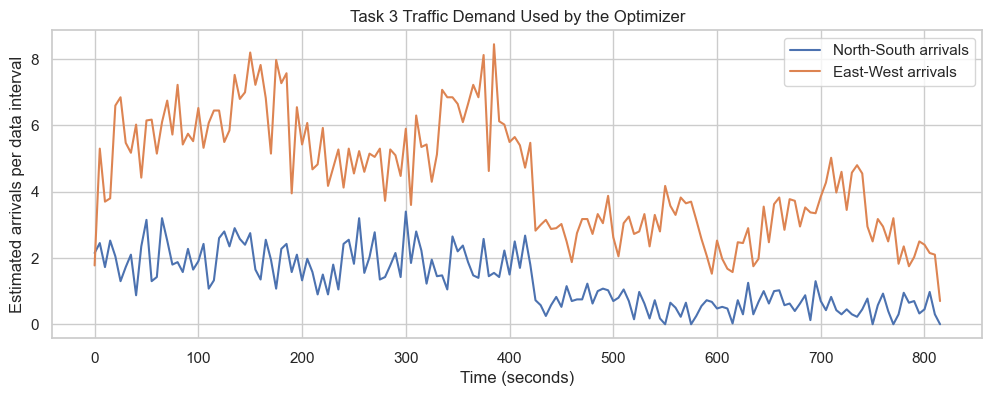

In [6]:
plot_traffic_demand(traffic)

### Cycle

In [7]:
MIN_GREEN = 10
MAX_GREEN = 90
LOST_TIME_SECONDS = 4
SATURATION_RATE = 1.5  # estimated vehicles discharged per green second

In [8]:
def decode_plan(individual):
    green_ns = int(np.clip(round(individual[0]), MIN_GREEN, MAX_GREEN))
    green_ew = int(np.clip(round(individual[1]), MIN_GREEN, MAX_GREEN))
    start_phase = int(round(individual[2])) % 2
    order = "NS first" if start_phase == 0 else "EW first"
    cycle_length = green_ns + green_ew + 2 * LOST_TIME_SECONDS

    return {
        "green_ns": green_ns, #Green duration for the north-south direction in seconds.
        "green_ew": green_ew, #Green duration for the east-west direction in seconds.
        "start_phase": start_phase,
        "order": order,
        "cycle_length": cycle_length,
    }


In [9]:
def build_cycle(plan):
    if plan["start_phase"] == 0:
        phases = [("NS", plan["green_ns"]), ("ALL_RED", LOST_TIME_SECONDS), ("EW", plan["green_ew"]), ("ALL_RED", LOST_TIME_SECONDS)]
    else:
        phases = [("EW", plan["green_ew"]), ("ALL_RED", LOST_TIME_SECONDS), ("NS", plan["green_ns"]), ("ALL_RED", LOST_TIME_SECONDS)]

    signal = []
    for phase, duration in phases:
        signal.extend([phase] * int(duration))
    return signal

In [30]:
def simulation(individual, flow_df, return_trace=False):
    plan = decode_plan(individual)
    signal = build_cycle(plan)

    queue_ns = 0.0 # Number of cars that are waiting on the road
    queue_ew = 0.0 
    total_wait = 0.0
    total_served_ns = 0.0 # Total vehicles served in the direction
    total_served_ew = 0.0 
    trace = []
    second = 0

    for _, row in flow_df.iterrows():
        ns_arrivals_per_second = row["ns_arrivals"] / TIME_STEP_SECONDS
        ew_arrivals_per_second = row["ew_arrivals"] / TIME_STEP_SECONDS

        for _ in range(TIME_STEP_SECONDS):
            queue_ns += ns_arrivals_per_second
            queue_ew += ew_arrivals_per_second

            total_wait += queue_ns + queue_ew

            active_phase = signal[second % plan["cycle_length"]]
            if active_phase == "NS":
                served = min(queue_ns, SATURATION_RATE)
                queue_ns -= served
                total_served_ns += served
            elif active_phase == "EW":
                served = min(queue_ew, SATURATION_RATE)
                queue_ew -= served
                total_served_ew += served

            second += 1

        if return_trace:
            trace.append({
                "time_s": row["time_s"],
                "queue_ns": queue_ns,
                "queue_ew": queue_ew,
                "total_queue": queue_ns + queue_ew,
                "phase": signal[(second - 1) % plan["cycle_length"]],
            })

    residual_queue = queue_ns + queue_ew
    objective = total_wait + residual_queue * plan["cycle_length"]

    result = {
        "plan": plan,
        "objective": objective,
        "total_wait": total_wait,
        "residual_queue": residual_queue,
        "served_ns": total_served_ns,
        "served_ew": total_served_ew,
    }

    if return_trace:
        result["trace"] = pd.DataFrame(trace)

    return result

### Genetic Algorithm

In [21]:
def create_individual():
    return [
        random.randint(MIN_GREEN, MAX_GREEN),
        random.randint(MIN_GREEN, MAX_GREEN),
        random.randint(0, 1),
    ]

In [31]:
def fitness_function(individual, flow_df):
    return -simulation(individual, flow_df)["objective"]

In [23]:
def selection(scored_population, k=3):
    candidates = random.sample(scored_population, k)
    return max(candidates, key=lambda item: item[1])[0].copy()

In [24]:
def crossover(parent1, parent2, crossover_rate=0.85):
    if random.random() > crossover_rate:
        return parent1.copy(), parent2.copy()

    point = random.randint(1, len(parent1) - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

In [25]:
def mutate(individual, mutation_rate=0.2):
    mutated = individual.copy()

    for i in [0, 1]:
        if random.random() < mutation_rate:
            mutated[i] += random.randint(-12, 12)
            mutated[i] = int(np.clip(mutated[i], MIN_GREEN, MAX_GREEN))

    if random.random() < mutation_rate:
        mutated[2] = 1 - int(mutated[2])

    return mutated

In [26]:

def run_ga(flow_df, generations=80, population_size=60, elite_size=4, mutation_rate=0.2, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    population = [create_individual() for _ in range(population_size)]
    history = []
    best_individual = None
    best_fitness = float("-inf")

    for generation in range(generations):
        scored = [(individual, fitness_function(individual, flow_df)) for individual in population]
        scored.sort(key=lambda item: item[1], reverse=True)

        generation_best, generation_best_fitness = scored[0]
        if generation_best_fitness > best_fitness:
            best_fitness = generation_best_fitness
            best_individual = generation_best.copy()

        history.append({
            "generation": generation,
            "best_wait": -best_fitness,
            "generation_best_wait": -generation_best_fitness,
            "average_wait": -np.mean([score for _, score in scored]),
        })

        next_population = [individual.copy() for individual, _ in scored[:elite_size]]

        while len(next_population) < population_size:
            parent1 = selection(scored)
            parent2 = selection(scored)
            child1, child2 = crossover(parent1, parent2)
            next_population.append(mutate(child1, mutation_rate))
            if len(next_population) < population_size:
                next_population.append(mutate(child2, mutation_rate))

        population = next_population

    return best_individual, pd.DataFrame(history)

### Optimisation

In [32]:
fixed_individual = [30, 30, 0]
best_individual, history = run_ga(traffic)

fixed_result = simulation(fixed_individual, traffic, return_trace=True)
optimized_result = simulation(best_individual, traffic, return_trace=True)

comparison = pd.DataFrame([
    {
        "strategy": "Fixed 30s / 30s",
        **fixed_result["plan"],
        "objective": fixed_result["objective"],
        "total_wait": fixed_result["total_wait"],
        "residual_queue": fixed_result["residual_queue"],
    },
    {
        "strategy": "GA optimized",
        **optimized_result["plan"],
        "objective": optimized_result["objective"],
        "total_wait": optimized_result["total_wait"],
        "residual_queue": optimized_result["residual_queue"],
    },
])

improvement = 100 * (fixed_result["objective"] - optimized_result["objective"]) / fixed_result["objective"]
print(f"Best individual: {best_individual}")
print(f"Optimized plan: {optimized_result['plan']}")
print(f"Objective improvement over fixed timing: {improvement:.2f}%")

Best individual: [22, 68, 0]
Optimized plan: {'green_ns': 22, 'green_ew': 68, 'start_phase': 0, 'order': 'NS first', 'cycle_length': 98}
Objective improvement over fixed timing: 76.52%


In [33]:
def visualize_results(history, comparison, fixed_result, optimized_result):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    axes[0, 0].plot(history["generation"], history["best_wait"], label="Best so far", linewidth=2)
    axes[0, 0].plot(history["generation"], history["average_wait"], label="Population average", alpha=0.75)
    axes[0, 0].set_title("Genetic Algorithm Convergence")
    axes[0, 0].set_xlabel("Generation")
    axes[0, 0].set_ylabel("Objective: vehicle-seconds waiting")
    axes[0, 0].legend()

    sns.barplot(data=comparison, x="strategy", y="objective", ax=axes[0, 1], palette=["#8da0cb", "#66c2a5"])
    axes[0, 1].set_title("Fixed Timing vs GA Optimized Timing")
    axes[0, 1].set_xlabel("")
    axes[0, 1].set_ylabel("Objective: vehicle-seconds waiting")

    fixed_trace = fixed_result["trace"]
    optimized_trace = optimized_result["trace"]
    axes[1, 0].plot(fixed_trace["time_s"], fixed_trace["total_queue"], label="Fixed timing", alpha=0.85)
    axes[1, 0].plot(optimized_trace["time_s"], optimized_trace["total_queue"], label="GA optimized", alpha=0.85)
    axes[1, 0].set_title("Queue Size Over Time")
    axes[1, 0].set_xlabel("Time (seconds)")
    axes[1, 0].set_ylabel("Estimated queued vehicles")
    axes[1, 0].legend()

    plan_table = comparison[["strategy", "green_ns", "green_ew", "order", "cycle_length"]].melt(
        id_vars=["strategy", "order"],
        value_vars=["green_ns", "green_ew", "cycle_length"],
        var_name="parameter",
        value_name="seconds",
    )
    sns.barplot(data=plan_table, x="parameter", y="seconds", hue="strategy", ax=axes[1, 1], palette=["#8da0cb", "#66c2a5"])
    axes[1, 1].set_title("Timing Parameters")
    axes[1, 1].set_xlabel("")
    axes[1, 1].set_ylabel("Seconds")
    axes[1, 1].legend(title="")

    plt.tight_layout()
    plt.show()

## Conclusion

The genetic algorithm successfully improved the traffic light schedule compared with the simple fixed timing strategy. The optimized solution used 22 seconds of green time for the north-south direction and 68 seconds for the east-west direction, with a total cycle length of 98 seconds. This result makes sense because the traffic data shows that east-west traffic demand is much higher than north-south demand, so the algorithm gives more green time to the busier direction. But it is not fully optimal due to in dataset there is no pedestrians.

Best individual: [22, 68, 0]
Optimized plan: {'green_ns': 22, 'green_ew': 68, 'start_phase': 0, 'order': 'NS first', 'cycle_length': 98}
Objective improvement over fixed timing: 76.52%


C:\Users\Alexander\AppData\Local\Temp\ipykernel_4080\375392797.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x="strategy", y="objective", ax=axes[0, 1], palette=["#8da0cb", "#66c2a5"])


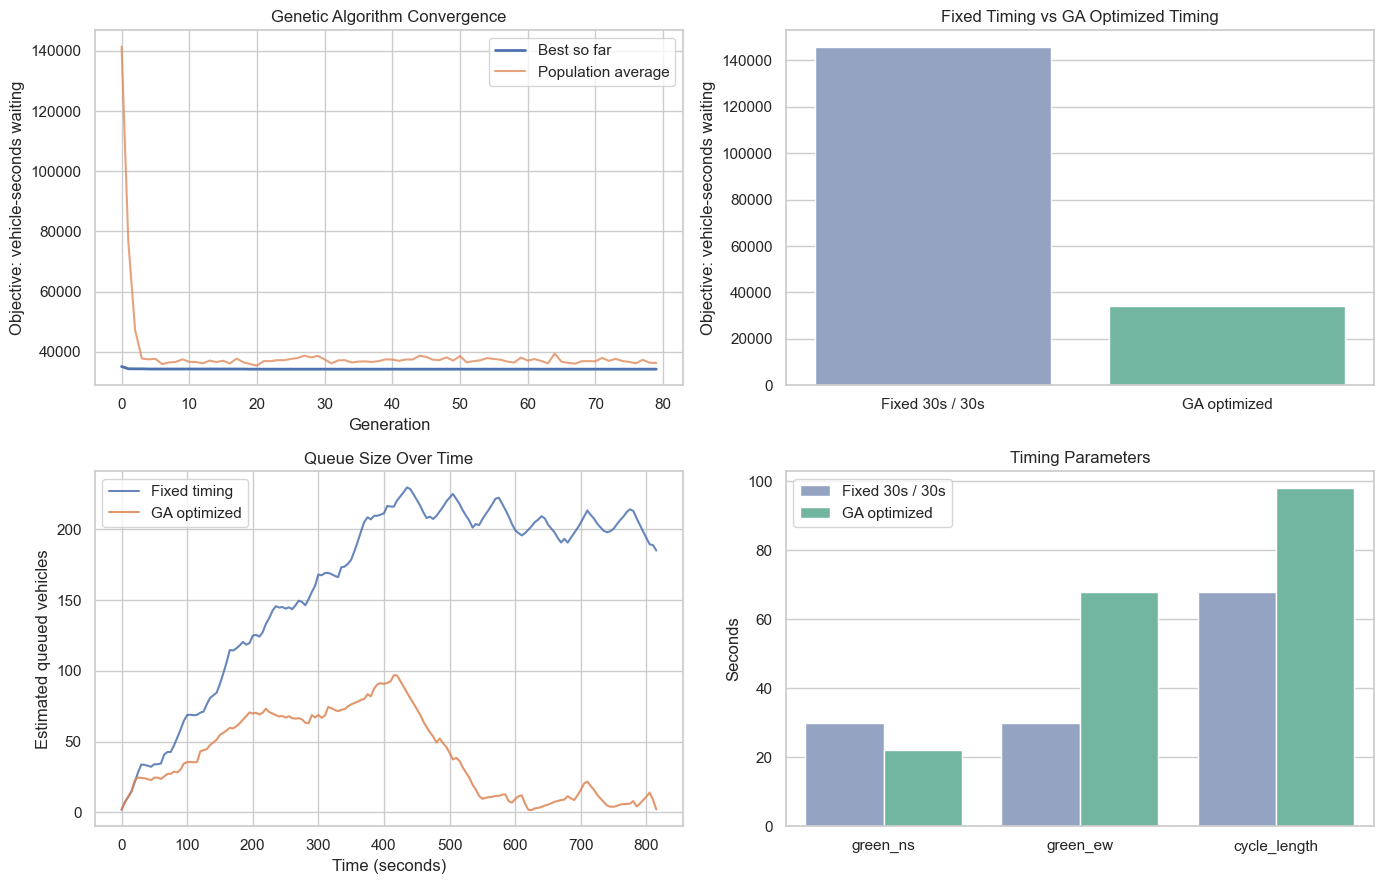

In [36]:
print(f"Best individual: {best_individual}")
print(f"Optimized plan: {optimized_result['plan']}")
print(f"Objective improvement over fixed timing: {improvement:.2f}%")
visualize_results(history, comparison, fixed_result, optimized_result)